# Proyek Klasifikasi Gambar: Intel Image Classification (https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

- **Nama:** Shava Selvia Ramadhani S
- **Email:** shashava05@gmail.com
- **ID Dicoding:** APC129D6X0506

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install split-folders tensorflowjs

import tensorflow as tf
import splitfolders
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## Data Preparation

### Data Loading

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [3]:
input_folder = os.path.join(path, "seg_train/seg_train")
output_folder = "/content/data_split"

print("Input folder:", input_folder)

Input folder: /kaggle/input/intel-image-classification/seg_train/seg_train


### Data Preprocessing

#### Split Dataset

In [4]:
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.2, 0.1)
)

Copying files: 14034 files [02:00, 116.26 files/s]


DATA GENERATOR

In [5]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "/content/data_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    "/content/data_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    "/content/data_split/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 9820 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 1410 images belonging to 6 classes.


## Modelling

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,603,398 (13.75 MB)

 Trainable params: 3,602,438 (13.74 MB)

 Non-trainable params: 960 (3.75 KB)

Compile & Callback

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.5072 - loss: 1.9836 - val_accuracy: 0.2846 - val_loss: 2.5045 - learning_rate: 0.0010
Epoch 2/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 204ms/step - accuracy: 0.6175 - loss: 1.0645 - val_accuracy: 0.6876 - val_loss: 0.8521 - learning_rate: 0.0010
Epoch 3/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 205ms/step - accuracy: 0.6522 - loss: 0.9547 - val_accuracy: 0.5464 - val_loss: 1.2002 - learning_rate: 0.0010
Epoch 4/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 205ms/step - accuracy: 0.6710 - loss: 0.8983 - val_accuracy: 0.7282 - val_loss: 0.7701 - learning_rate: 0.0010
Epoch 5/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 204ms/step - accuracy: 0.6952 - loss: 0.8410 - val_accuracy: 0.6680 - val_loss: 0.9986 - learning_rate: 0.0010
Epoch 6/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 203ms/step - accuracy: 0.7276 - loss: 0.7760 - val_accuracy: 0.5571 - val_loss: 1.4154 - learning_rate: 0.0010
Epoch 7/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.7

## Evaluasi dan Visualisasi

In [ ]:
# Evaluasi
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8894 - loss: 0.3463
Test Accuracy: 0.8893616795539856


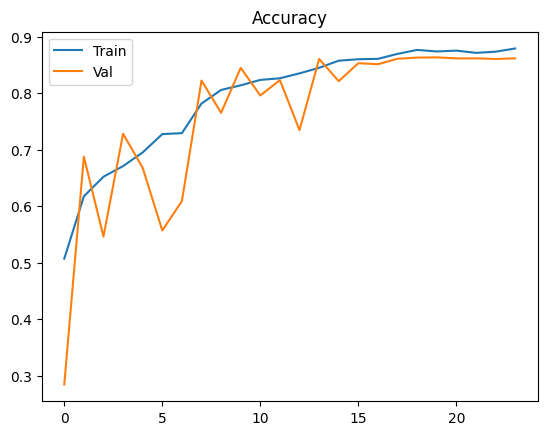

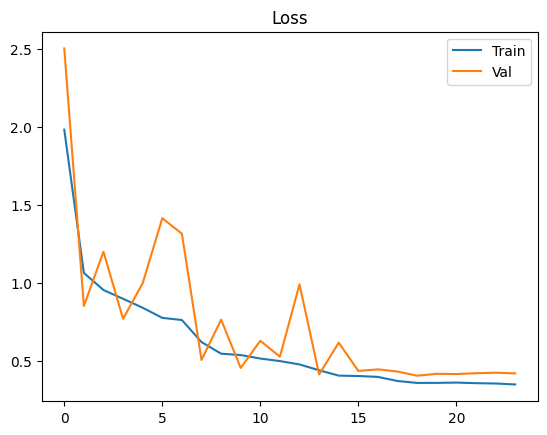

In [ ]:
# Visualisasi
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Val'])
plt.show()

## Konversi Model

SavedModel

In [ ]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137446416040208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416041744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416043664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416041360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416041168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416042704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416043856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416044240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416045392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416045584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137446416043472: Te

TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Label

In [ ]:
labels = list(train_data.class_indices.keys())

with open("label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

TFJS

In [ ]:
!tensorflowjs_converter \
--input_format=tf_saved_model \
saved_model \
tfjs_model

2026-04-27 14:13:25.958516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777299205.978854   10902 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777299205.985575   10902 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777299206.001704   10902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777299206.001745   10902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777299206.001750   10902 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [ ]:
!pip install gradio

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step


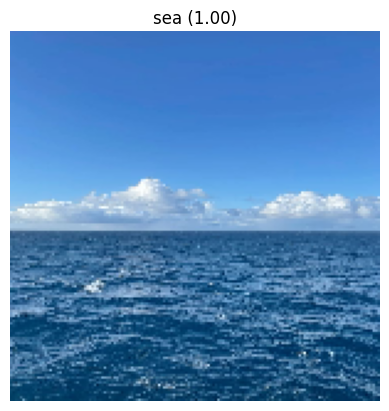

Prediksi: sea
Confidence: 0.9999542


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load model
infer_model = tf.keras.Sequential([
    tf.keras.layers.TFSMLayer("saved_model", call_endpoint="serve")
])

# Load label
with open("label.txt") as f:
    class_names = [line.strip() for line in f.readlines()]

# Path gambar
img_path = "/sea.jpg"  # pastikan file ini ADA

# Load & preprocess
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediksi
pred = infer_model.predict(img_array)

predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# 🔥 TAMPILKAN GAMBAR
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

print("Prediksi:", predicted_class)
print("Confidence:", confidence)

In [ ]:
!pip freeze > requirements.txt